# 2026-01-26 Chebyshev collocation

## Last time

* Techniques for boundary conditions
* Fourier analysis of stencils

## Today

* Conditioning of Vandermonde matrices
* Chebyshev polynomials
* Solving Poisson using Chebyshev polynomials

In [103]:
using Plots
default(linewidth=3)
using LinearAlgebra

function vander(x, k=nothing)
    if k === nothing
        k = length(x)
    end
    V = ones(length(x), k)
    for j = 2:k
        V[:, j] = V[:, j-1] .* x
    end
    V
end

function fdstencil(source, target, k)
    "kth derivative stencil from source to target"
    x = source .- target
    V = vander(x)
    rhs = zero(x)'
    rhs[k+1] = factorial(k)
    rhs / V
end

function poisson_fd(x, spoints, forcing; left=(0, zero), right=(0, zero))
    n = length(x)
    L = zeros(n, n)
    rhs = forcing.(x)
    for i in 2:n-1
        jleft = min(max(1, i-spoints÷2), n-spoints+1)
        js = jleft : jleft + spoints - 1
        L[i, js] = -fdstencil(x[js], x[i], 2)
    end
    L[1,1:spoints] = fdstencil(x[1:spoints], x[1], left[1])
    L[n,n-spoints+1:n] = fdstencil(x[n-spoints+1:n], x[n], right[1])
    rhs[1] = left[2](x[1])
    rhs[n] = right[2](x[n])
    L, rhs
end
    
function my_spy(A)
    cmax = norm(vec(A), Inf)
    s = max(1, ceil(120 / size(A, 1)))
    spy(A, marker=(:square, s), c=:diverging_rainbow_bgymr_45_85_c67_n256, clims=(-cmax, cmax))
end

my_spy (generic function with 1 method)

# Fourier analysis of stencils

Consider the plane waves $\phi(x, \theta) = e^{i\theta x}$.

Sample $\phi$ on a discrete grid $x = \mathbb Z$ and apply the stencil
\begin{align}
S \phi(x, \theta) &= s_{-1} \phi(x-1, \theta) + s_{0} \phi(x, \theta) + s_1 \phi(x+1,\theta) \\
&= \Big( s_{-1} e^{-i\theta} + s_0 + s_{1} e^{i\theta} \Big) \phi(x, \theta)
\end{align}
With $S = \begin{bmatrix} -1 & 2 & -1 \end{bmatrix}$, we get
$$S \phi(x, \theta) = \underbrace{(2 - 2 \cos\theta)}_{\hat S(\theta)} \phi(x, \theta)$$
We call $\hat S(\theta)$ the *symbol* of the operator.
What is the symbol of the continuous second derivative?

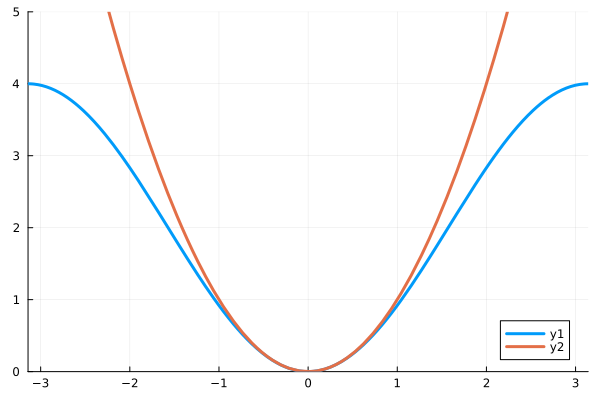

In [69]:
plot([theta -> 2 - 2*cos(theta),
        theta -> theta^2],
    xlims=(-pi, pi), ylim=(0, 5))

# Numerically computing symbols

In [70]:
function symbol(S, theta)
    if length(S) % 2 != 1
        error("Length of stencil must be odd")
    end
    w = length(S) ÷ 2
    phi = exp.(1im * (-w:w) * theta')
    vec(S * phi) # not! (S * phi)'
end

theta = LinRange(-pi, pi, 10)
symbol([-.5 0 .5], theta)
#symbol([1 -2 1], theta)

10-element Vector{ComplexF64}:
 0.0 - 1.2246467991473532e-16im
 0.0 - 0.6427876096865395im
 0.0 - 0.9848077530122081im
 0.0 - 0.8660254037844388im
 0.0 - 0.34202014332566877im
 0.0 + 0.34202014332566877im
 0.0 + 0.8660254037844385im
 0.0 + 0.9848077530122081im
 0.0 + 0.6427876096865395im
 0.0 + 1.2246467991473532e-16im

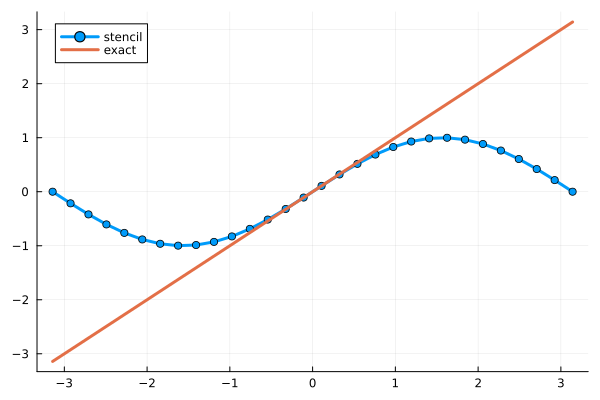

In [107]:
function plot_symbol(S, deriv, n_theta=30)
    theta = LinRange(-pi, pi, n_theta)
    sym = symbol(S, theta)
    rsym = real.((-1im)^deriv * sym)
    fig = plot(theta, rsym, marker=:circle, label="stencil")
    plot!(fig, th -> th^deriv, label="exact")
    fig
end

#plot_symbol([-1 1 0], 1)
plot_symbol([-.5 0 .5], 1)
#plot_symbol([1 -2 1], 2)

# Stencils of high-order operators

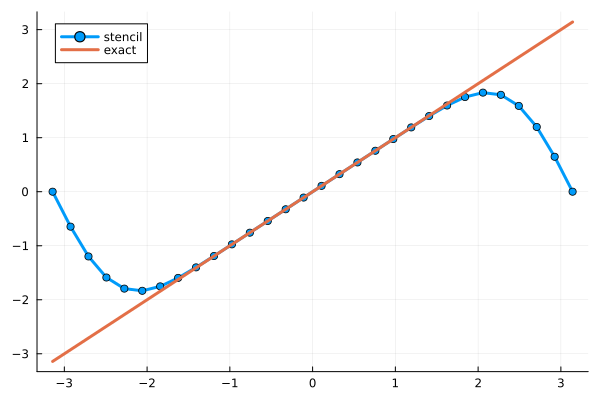

In [72]:
x = -5:5
plot_symbol(fdstencil(x, 0, 1), 1)

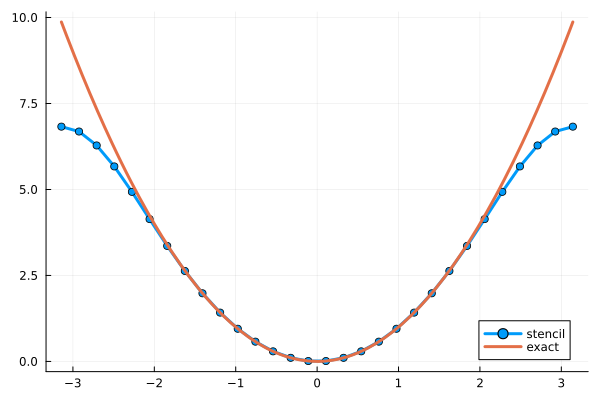

In [73]:
x = -5:5
plot_symbol(fdstencil(x, 0, 2), 2)

# Outlook on Fourier methods

* the Fourier modes $e^{i\theta x}$ and their multi-dimensional extensions are eigenvectors of **all** stencil-type operations
* "high frequencies" $[-\pi, \pi) \setminus [-\pi/2, \pi/2)$ are generally poorly resolved so we need to use a grid fine enough that important features are at low frequencies $[-\pi/2, \pi/2)$
* same technique can be used to study the inverse (and approximations thereof), as with multigrid and multilevel domain decomposition methods (later in the course)
* these methods can also be framed within the theory of (block) Toeplitz matrices

# Visualizing matrix transformations

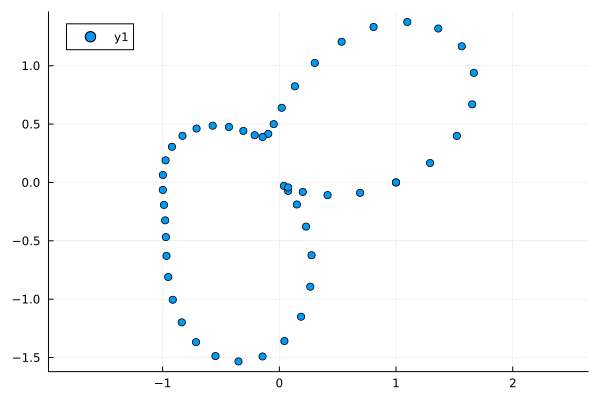

In [74]:
function peanut()
    theta = LinRange(0, 2*pi, 50)
    r = 1 .+ .4*sin.(3*theta) + .6*sin.(2*theta)
    x = r .* cos.(theta)
    y = r .* sin.(theta)
    x, y
end
x, y = peanut()
scatter(x, y, aspect_ratio=:equal)

Group these points into a $2\times n$ matrix $X$. Note that multiplication by any matrix $A$ is applied to each column separately, i.e.,

$$ A \underbrace{\Bigg[ \mathbf x_1 \Bigg| \mathbf x_2 \Bigg| \dotsb \Bigg]}_X = \Bigg[ A \mathbf x_1 \Bigg| A \mathbf x_2 \Bigg| \dotsb \Bigg] $$

In [75]:
X = [x y]'
size(X)

(2, 50)

# Visualizing the Singular Value Decomposition

2-element Vector{Float64}:
 1.5733910162799942
 0.6531017018698968

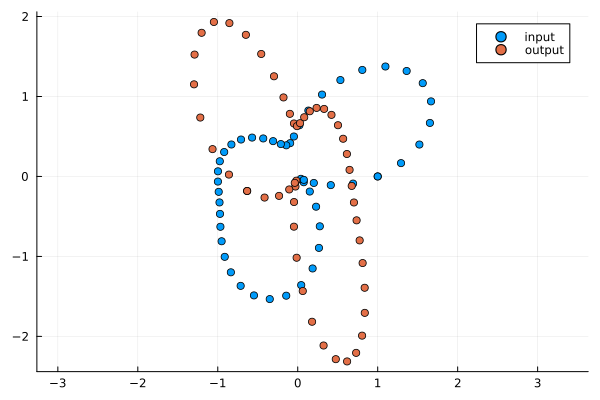

In [109]:
function tplot(A)
    x, y = peanut()
    X = [x y]'
    Y = A * X
    scatter(X[1,:], X[2,:], label="input", aspect_ratio=:equal)
    scatter!(Y[1,:], Y[2,:], label="output")
end

A = randn(2, 2)
display(svdvals(A))
tplot(A)

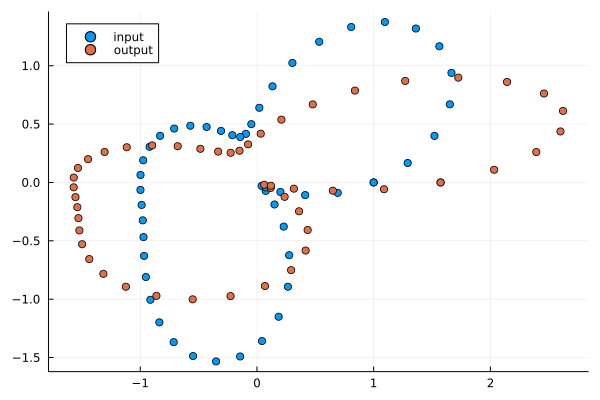

In [113]:
U, S, V = svd(A)
tplot(diagm(S))

# Condition number of interpolation

In [119]:
n = 20
source = LinRange(-1, 1, n)
target = LinRange(-1, 1, 100)
P = vander(source)
A = vander(target, n) / P
svdvals(A)

20-element Vector{Float64}:
 4141.821782616751
  756.1886116478423
   11.201394442792848
    5.2003668113709685
    2.3263899157147714
    2.288653157539752
    2.282662654802775
    2.2826582312560655
    2.2826577307738387
    2.282657730758319
    2.282657729732329
    2.2826577141901727
    2.2825938632415284
    2.2823522003372787
    2.2484549739876982
    2.2449230244011553
    1.9014541632771662
    1.7794033224059735
    1.0093167855352632
    1.0064482710754257

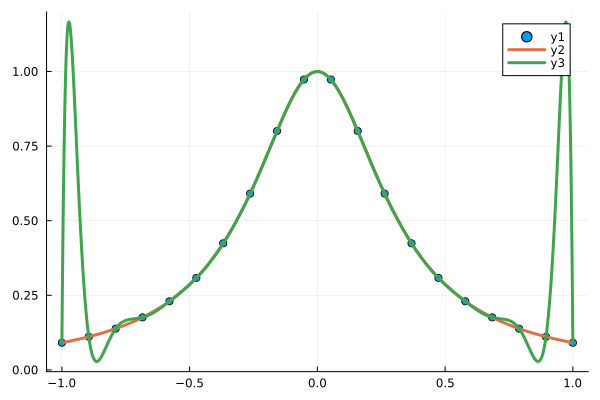

In [120]:
runge(x) = 1 / (1 + 10*x^2)
y = runge.(source)
scatter(source, y)
plot!([runge,
        x -> (vander([x], n) / P * y)[1]])
# plot!(target, A * y)

# The bad singular vectors

$$ A = U \Sigma V^T $$


In [124]:
n = 20
source = LinRange(-1, 1, n)
target = LinRange(-1, 1, 100)
P = vander(source)
A = vander(target, n) / P
U, S, V = svd(A)
S

20-element Vector{Float64}:
 4141.821782616753
  756.1886116478419
   11.201394442792855
    5.200366811370964
    2.3263899157147665
    2.2886531575397515
    2.282662654802776
    2.2826582312560686
    2.2826577307738343
    2.2826577307583182
    2.2826577297323283
    2.2826577141901723
    2.282593863241528
    2.2823522003372774
    2.2484549739876973
    2.2449230244011558
    1.9014541632771664
    1.779403322405974
    1.0093167855352634
    1.006448271075426

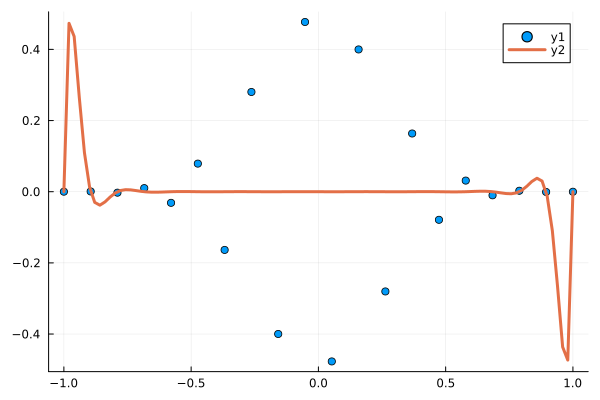

In [126]:
scatter(source, V[:,1])
plot!(target, U[:,1])

# Choosing the source points

In [82]:
CosRange(a, b, n) = (a + b)/2 .+ (b - a)/2 * cos.(LinRange(-pi, 0, n))

CosRange (generic function with 1 method)

In [127]:
n = 20
source = CosRange(-1, 1, n)
target = LinRange(-1, 1, 100)
P = vander(source)
A = vander(target, n) / P
svdvals(A)

20-element Vector{Float64}:
 2.8563807370962597
 2.8414668608893727
 2.820236386666684
 2.782971972955598
 2.7474280450564037
 2.684651346438173
 2.6367813665084734
 2.545083971259591
 2.486134057074219
 2.361948553390591
 2.2916184165593356
 2.1320708818298613
 2.046030538964409
 1.8547347713982336
 1.7347507488576817
 1.550199469282724
 1.3481998183204564
 1.2519073525927882
 0.9462546371476172
 0.9419175178451628

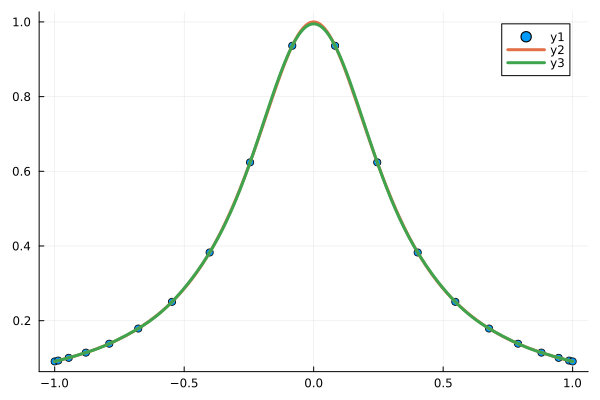

In [128]:
runge(x) = 1 / (1 + 10*x^2)
y = runge.(source)
scatter(source, y)
plot!([runge,
        x -> (vander([x], n) / P * y)[1]])

# Condition number of interpolation on `CosRange` points

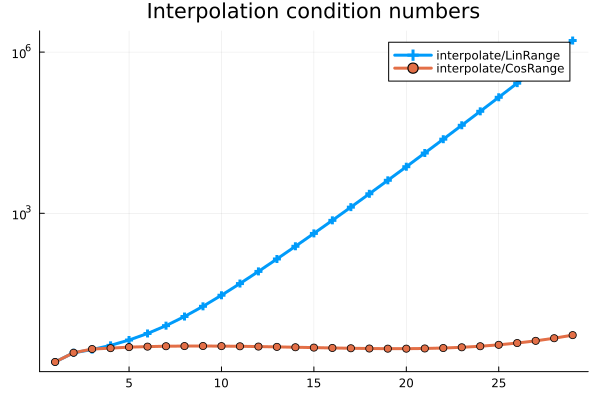

In [85]:
interpolate(source, target=LinRange(-1, 1, 100)) = vander(target, length(source)) / vander(source)

plot_cond(mat, points) = plot!([
        cond(mat(points(-1, 1, n)))
        for n in 2:30], label="$mat/$points", marker=:auto, yscale=:log10)

plot(title="Interpolation condition numbers")
plot_cond(interpolate, LinRange)
plot_cond(interpolate, CosRange)

# Vandermonde conditioning, stable algorithms

It is possible for interpolation to be well-conditioned, but construct it from ill-conditioned pieces.

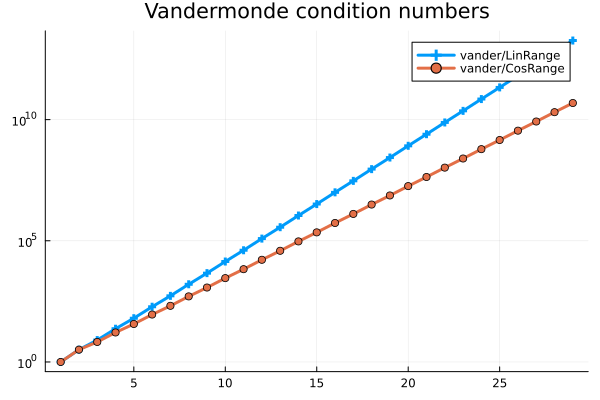

In [86]:
plot(title="Vandermonde condition numbers")
plot_cond(vander, LinRange)
plot_cond(vander, CosRange)

# Chebyshev polynomials

In [87]:
function vander_chebyshev(x, n=nothing)
    if isnothing(n)
        n = length(x) # Square by default
    end
    m = length(x)
    T = ones(m, n)
    if n > 1
        T[:, 2] = x
    end
    for k in 3:n
        T[:, k] = 2 * x .* T[:,k-1] - T[:, k-2]
    end
    T
end

vander_chebyshev (generic function with 2 methods)

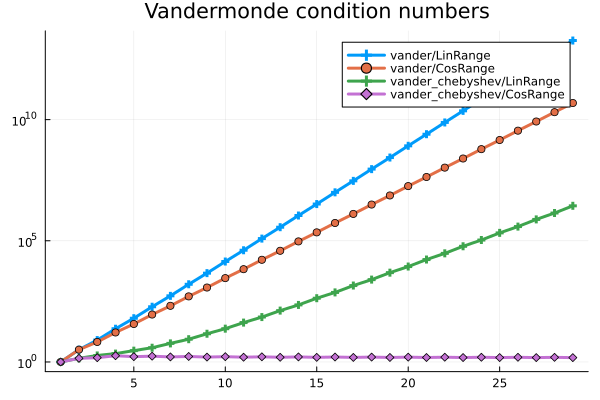

In [88]:
plot(title="Vandermonde condition numbers")
plot_cond(vander, LinRange)
plot_cond(vander, CosRange)
plot_cond(vander_chebyshev, LinRange)
plot_cond(vander_chebyshev, CosRange)

# Derivation of Chebyshev polynomials (supplemental)

Chebyshev polynomials are defined for non-negative integar $n$ as $$ T_n(x) = \cos (n \arccos(x)) .$$
This turns out to be a polynomial, but it's not obvious why.
Recall $$ \cos(a + b) = \cos a \cos b - \sin a \sin b .$$
Let $y = \arccos x$ and check
$$ \begin{split}
    T_{n+1}(x) &= \cos \big( (n+1) y \big) = \cos ny \cos y - \sin ny \sin y \\
    T_{n-1}(x) &= \cos \big( (n-1) y \big) = \cos ny \cos y + \sin ny \sin y
\end{split}$$
Adding these together produces
$$ T_{n+1}(x) + T_{n-1}(x) = 2\cos ny \cos y = 2 x \cos ny = 2 x T_n(x) $$
which yields a convenient recurrence:
$$\begin{split}
T_0(x) &= 1 \\
T_1(x) &= x \\
T_{n+1}(x) &= 2 x T_n(x) - T_{n-1}(x)
\end{split}$$

# Lagrange interpolating polynomials

Find the unique polynomial that is 0 at all but one `source` point.

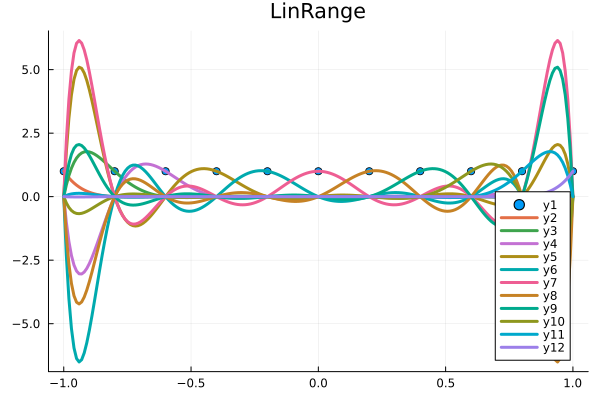

In [89]:
source = LinRange(-1, 1, 11)
target = LinRange(-1, 1, 200)
scatter(source, one.(source), title="LinRange")
plot!(target, interpolate(source, target))

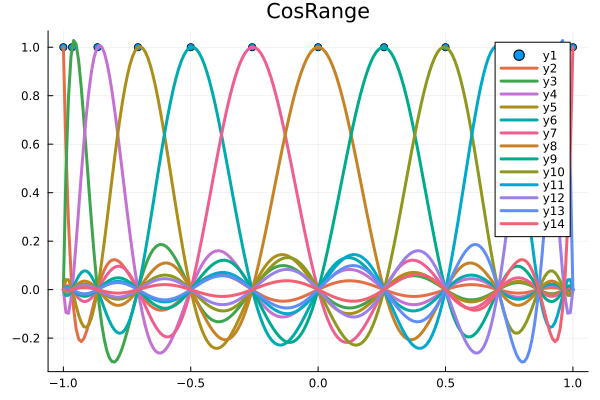

In [90]:
source = CosRange(-1, 1, 13)
target = LinRange(-1, 1, 200)
scatter(source, one.(source), title="CosRange")
plot!(target, interpolate(source, target))

# Differentiating via Chebyshev

We can differentiate Chebyshev polynomials using the recurrence

$$ \frac{T_k'(x)}{k} = 2 T_{k-1}(x) + \frac{T_{k-2}'(x)}{k-2} $$

which we can differentiate to evaluate higher derivatives.

In [91]:
function chebdiff(x, n=nothing)
    T = vander_chebyshev(x, n)
    m, n = size(T)
    dT = zero(T)
    dT[:,2:3] = [one.(x) 4*x]
    for j in 3:n-1
        dT[:,j+1] = j * (2 * T[:,j] + dT[:,j-1] / (j-2))
    end
    ddT = zero(T)
    ddT[:,3] .= 4
    for j in 3:n-1
        ddT[:,j+1] = j * (2 * dT[:,j] + ddT[:,j-1] / (j-2))
    end
    T, dT, ddT
end

chebdiff (generic function with 2 methods)

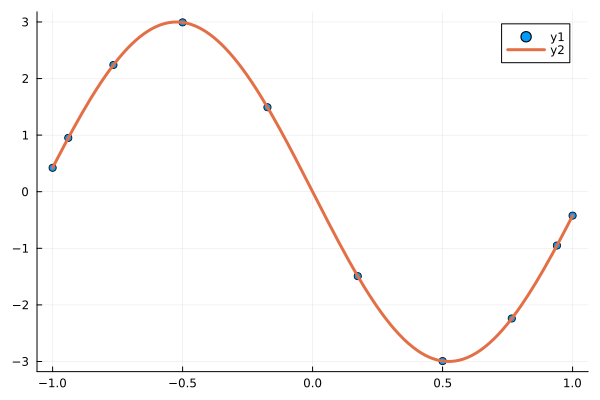

In [135]:
x = CosRange(-1, 1, 10)
T, dT, ddT = chebdiff(x)
c = T \ cos.(3x)
scatter(x, dT * c)
plot!(x -> -3sin(3x))

# "Nodal" (Lagrange interpolating polynomials) versus "Modal" bases

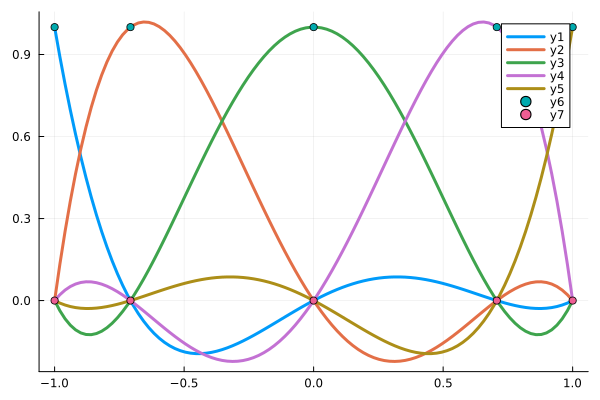

In [137]:
n = 5
x = CosRange(-1, 1, n)
xx = LinRange(-1, 1, 100)
Tx = vander_chebyshev(x)
Txx, dTxx, ddTxx = chebdiff(xx, n)
plot(xx, Txx / Tx)
scatter!(x, [one.(x) zero.(x)])
#my_spy(Tx)

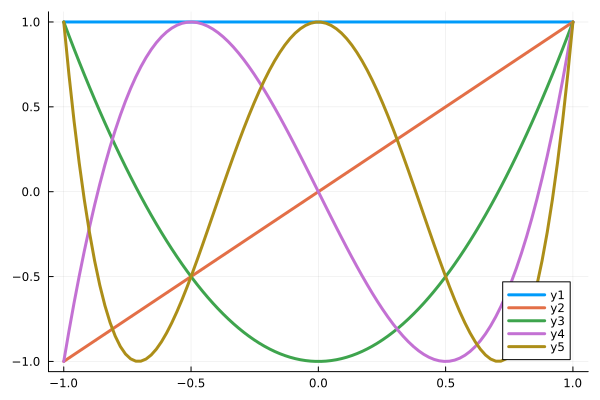

In [106]:
plot(xx, Txx)

# Solving a BVP on Chebyshev nodes

In [93]:
function poisson_cheb(n, rhsfunc, leftbc=(0, zero), rightbc=(0, zero))
    x = CosRange(-1, 1, n)
    T, dT, ddT = chebdiff(x)
    L = -ddT
    rhs = rhsfunc.(x)
    for (index, deriv, func) in
            [(1, leftbc...), (n, rightbc...)]
        L[index,:] = (T, dT)[deriv+1][index,:]
        rhs[index] = func(x[index])
    end
    x, L / T, rhs
end

poisson_cheb (generic function with 3 methods)

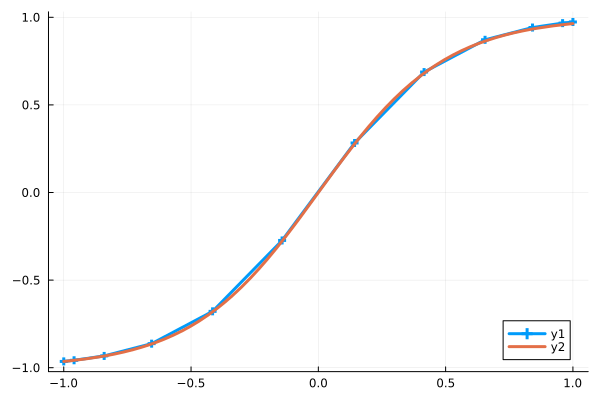

In [94]:
manufactured(x) = tanh(2x)
d_manufactured(x) = 2*cosh(2x)^-2
mdd_manufactured(x) = 8 * tanh(2x) / cosh(2x)^2
x, A, rhs = poisson_cheb(12, mdd_manufactured,
    (0, manufactured), (1, d_manufactured))
plot(x, A \ rhs, marker=:auto)
plot!(manufactured, legend=:bottomright)

# "spectral" (exponential) convergence

In [99]:
function poisson_fd_error(n; spoints=3)
    x = LinRange(-2, 2, n)
    L, rhs = poisson_fd(x, spoints, x -> 2 * tanh(x) / cosh(x)^2,
        left = (0, tanh),
        right = (1, x -> cosh(x)^-2))
    u = L \ rhs
    norm(u - tanh.(x), Inf)
end

poisson_fd_error (generic function with 1 method)

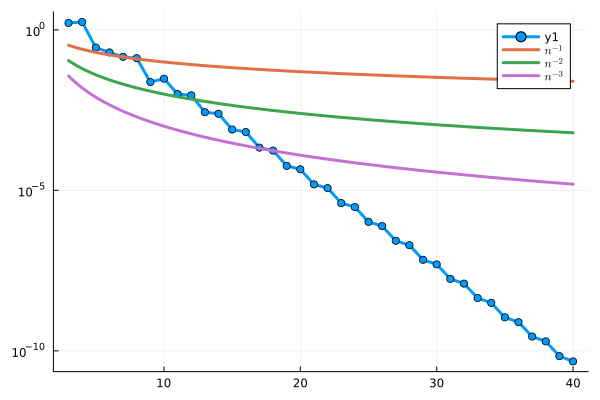

In [141]:
function poisson_error(n)
    x, A, rhs = poisson_cheb(n, mdd_manufactured, (0, manufactured), (1, d_manufactured))
    u = A \ rhs
    norm(u - manufactured.(x), Inf)
end

ns = 3:40
plot(ns, abs.(poisson_error.(ns)), marker=:circle, yscale=:log10)
ps = [1 2 3]
plot!([n -> n^-p for p in ps], label=map(p -> "\$n^{-$p}\$", ps))

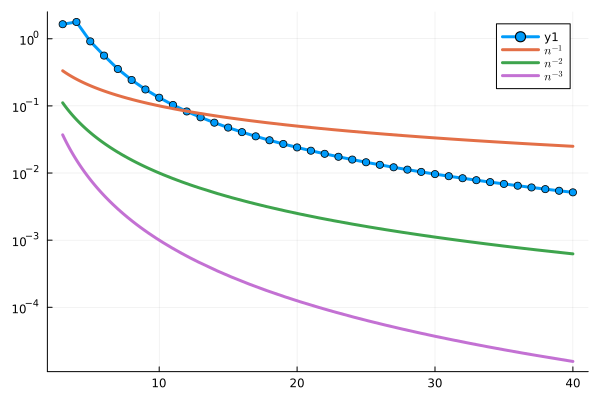

In [101]:
plot(ns, [poisson_fd_error(n, spoints=3) for n in ns], 
    marker=:circle, yscale=:log10)
plot!([n -> n^-p for p in ps], label=map(p -> "\$n^{-$p}\$", ps))